In [10]:
import emcee
import numpy as np
import corner


class MCMC:
    """basic wrapper a emcee"""

    def __init__(self, model, **kwargs) -> None:
        self._model = model
        self.esembler_kwargs = kwargs

    @property
    def model(self):
        return self._model

    def logprior(self, theta):
        # Controlla se ogni parametro è all'interno dei suoi bounds
        for param, val in zip(self.model.free_parameters, theta):
            if val < param.bounds[0] or val > param.bounds[1]:
                return -np.inf
        return 0.0

    def loglike(self, theta, xdata, ydata, yerr):
        """
        Calcola la log-likelihood dati i dati e il modello.
        Assumiamo errori gaussiani indipendenti.
        """
        ymodel = self.model.call([xdata], *theta)
        residuals = ydata - ymodel
        ln = -0.5 * np.sum((residuals**2 / yerr**2) + np.log(2 * np.pi * yerr**2))
        return ln

    def log_probability(self, theta, xdata, ydata, yerr):
        lp = self.logprior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + self.loglike(theta, xdata, ydata, yerr)

    def fit(
        self,
        grid,
        data,
        theta0,
        error,
        nwalkers=32,
        nsteps=5000,
        discard=100,
        thin=15,
        **kwargs,
    ):
        # 1 check number of dimensions
        if len(grid) != self.model.n_dim:
            raise ValueError("Grid dimension do not match model dimension")

        # 2 see if theta0 is ok
        # theta0 può essere un singolo vettore (ndim,) o già un array (nwalkers, ndim)
        theta0 = np.array(theta0)
        if theta0.ndim == 1:
            # Se è un singolo vettore, creiamo un ensemble di partenza
            ndim = len(theta0)
            pos = theta0 + 1e-4 * np.random.randn(nwalkers, ndim)
        else:
            # Se è già bidimensionale, assumiamo che sia della forma (nwalkers, ndim)
            pos = theta0
            nwalkers, ndim = pos.shape

        # Controlla la compatibilità del modello con i dati
        tmp = self.model.call(grid, *pos[0])
        if np.shape(tmp) != np.shape(data):
            raise ValueError("Data dimension do not match model outputs")

        # Aggiorna i kwargs con quelli passati
        self.esembler_kwargs.update(**kwargs)

        # Crea il sampler
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            self.log_probability,
            args=(grid, data, error),
            **self.esembler_kwargs,
        )

        # Esegui l'MCMC
        sampler.run_mcmc(pos, nsteps, progress=True)

        # Estrai i campioni
        flat_samples = sampler.get_chain(discard=discard, thin=thin, flat=True)

        # Plot con corner
        labels = self.model.parameters_names
        fig = corner.corner(flat_samples, labels=labels)

        return flat_samples, fig


In [2]:
from model import Model
import matplotlib.pyplot as plt

def line(x,a,b):
    return a*x + b

line_model = Model.wrap(line, grid_variables=["x"])
print(line_model)

MODEL NAME: SimpleModel 
FREE PARAMS: 2
GRID VARIABLES: ['x']
N-DIM: 1
------------------------------------------------------------
     NAME            VALUE      IS-FROZEN  BOUNDS              
------------------------------------------------------------
0    a               1.00       No         (-inf, inf)         
1    b               1.00       No         (-inf, inf)         



Text(0, 0.5, 'y')

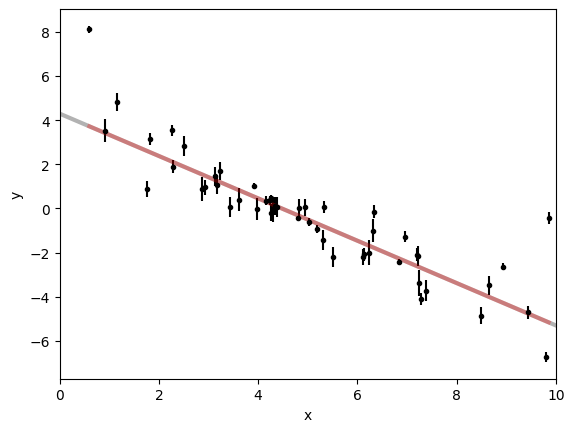

In [3]:


np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = line(x, m_true,b_true)
y_model = line_model(x, a=m_true, b=b_true)

y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, y_model, "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

In [4]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    #model = line_model.call([x], *theta[:-1])
    #log_f = theta[-1]
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

32

In [19]:
pos = np.array([-1.003,4.528,0.454]) + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(pos, 5000, progress=True)


100%|██████████| 5000/5000 [00:04<00:00, 1021.44it/s]


State([[-1.01735973  4.61528254 -0.81131404]
 [-0.88463709  4.02466638 -0.61637641]
 [-1.12407313  5.02400889 -0.87426389]
 [-0.89372165  4.00636637 -0.62937515]
 [-1.03112119  4.69613692 -0.88292847]
 [-0.89907292  4.01750412 -0.70215679]
 [-0.94818601  4.2874146  -0.71279186]
 [-0.96422863  4.31351576 -0.37696642]
 [-0.85726537  3.89748877 -0.60966632]
 [-0.81395895  3.73148847 -0.51871366]
 [-0.91696446  4.21961918 -0.64113093]
 [-1.01737155  4.49041196 -0.91372502]
 [-1.14582171  5.12493702 -0.50150756]
 [-0.9917439   4.49387194 -0.81167177]
 [-1.06818899  4.78536985 -0.59095258]
 [-1.07976404  4.8930262  -0.9729671 ]
 [-0.89462922  4.07137784 -0.52153635]
 [-0.96094277  4.30712557 -0.84176985]
 [-1.01085252  4.51726748 -0.74082417]
 [-0.95729438  4.27362947 -0.37089505]
 [-1.07722756  4.87315612 -0.93097045]
 [-1.06001901  4.78441745 -0.84935923]
 [-1.03432927  4.64225183 -0.86772158]
 [-0.97512864  4.31053184 -0.72584101]
 [-1.06005643  4.7736894  -0.70566647]
 [-1.01699523  4.63

(10432, 3)


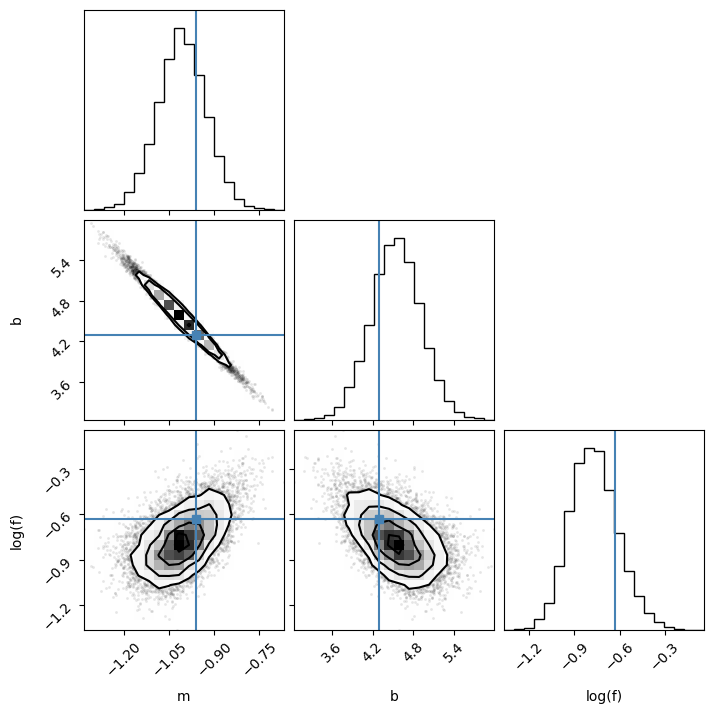

In [16]:
import corner
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)
labels = ["m", "b", "log(f)"]

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)


  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [00:06<00:00, 823.68it/s]


(array([[-1.08148577,  5.30858978],
        [-1.10878846,  5.4100297 ],
        [-1.10594243,  5.40210479],
        ...,
        [-1.10311857,  5.42897641],
        [-1.10357853,  5.41451399],
        [-1.12721172,  5.58223518]]),
 <Figure size 550x550 with 4 Axes>)

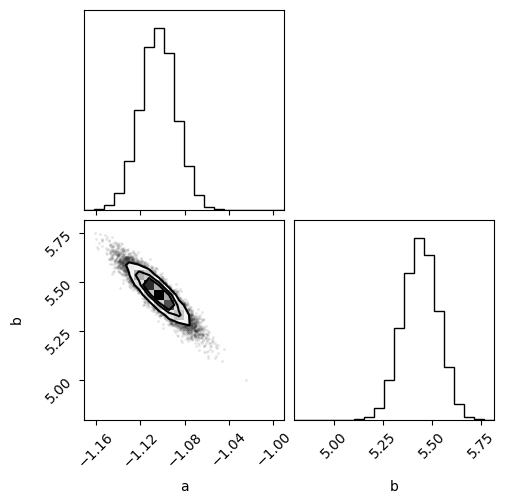

In [20]:
wrapper = MCMC(line_model)

wrapper.fit(grid = np.array([x]),
            data = y,
            error = yerr,
            theta0 = np.array([1,2]),
            #nwalkers=1,
            #ndim=2
            )